In [8]:
import pandas as pd
import joblib

In [9]:
model = joblib.load("manganese_xgboost.pkl")

In [10]:
df = pd.read_csv("input.csv")

In [11]:
print(df.shape)

(3567915, 29)


In [12]:
print(df.columns)

Index(['prediction_cell_id', 'district', 'row', 'col', 'x_utm_m', 'y_utm_m',
       'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8A', 'B11', 'B12', 'S2_NDVI',
       'Fe_Oxide_Proxy', 'SWIR_Ratio', 'LST_C', 'VV', 'VH', 'VV_VH_Difference',
       'lithology_class_id', 'geomorphology_class_id',
       'distance_to_lineament_m', 'lineament_density_1km',
       'distance_to_structure_m', 'structure_density_1km',
       'bhuvan_lulc_class_id'],
      dtype='object')


In [13]:
print(df.dtypes)

prediction_cell_id           int64
district                    object
row                          int64
col                          int64
x_utm_m                    float64
y_utm_m                    float64
B2                         float64
B3                         float64
B4                         float64
B5                         float64
B6                         float64
B7                         float64
B8A                        float64
B11                        float64
B12                        float64
S2_NDVI                    float64
Fe_Oxide_Proxy             float64
SWIR_Ratio                 float64
LST_C                      float64
VV                         float64
VH                         float64
VV_VH_Difference           float64
lithology_class_id           int64
geomorphology_class_id       int64
distance_to_lineament_m    float64
lineament_density_1km      float64
distance_to_structure_m    float64
structure_density_1km      float64
bhuvan_lulc_class_id

In [14]:
drop_cols = [
    'prediction_cell_id',
    'district',
    'row',
    'col',
    'x_utm_m',
    'y_utm_m'
]

X_new = df.drop(columns=drop_cols)

In [15]:
print(X_new.shape)

(3567915, 23)


In [16]:
df = df.rename(columns={
    "B2": "S2_B2_Blue",
    "B3": "S2_B3_Green",
    "B4": "S2_B4_Red",
    "B5": "S2_B5_RedEdge1",
    "B6": "S2_B6_RedEdge2",
    "B7": "S2_B7_RedEdge3",
    "B8A": "S2_B8A_NIR",
    "B11": "S2_B11_SWIR1",
    "B12": "S2_B12_SWIR2",
    "S2_NDVI": "S2_NDVI",   
    "Fe_Oxide_Proxy": "S2_Fe_Oxide_Proxy",
    "SWIR_Ratio": "S2_SWIR_Ratio",
    "LST_C": "Landsat_LST_C",
    "VV": "S1_VV_dB",
    "VH": "S1_VH_dB",
    "VV_VH_Difference": "S1_VV_VH_Difference_dB"
})

In [17]:
feature_cols = [
    'S2_B2_Blue',
    'S2_B3_Green',
    'S2_B4_Red',
    'S2_B5_RedEdge1',
    'S2_B6_RedEdge2',
    'S2_B7_RedEdge3',
    'S2_B8A_NIR',
    'S2_B11_SWIR1',
    'S2_B12_SWIR2',
    'S2_NDVI',
    'S2_Fe_Oxide_Proxy',
    'S2_SWIR_Ratio',
    'Landsat_LST_C',
    'S1_VV_dB',
    'S1_VH_dB',
    'S1_VV_VH_Difference_dB',
    'lithology_class_id',
    'geomorphology_class_id',
    'distance_to_lineament_m',
    'lineament_density_1km',
    'distance_to_structure_m',
    'structure_density_1km',
    'bhuvan_lulc_class_id'
]

X_new = df[feature_cols]

In [18]:
probs = model.predict_proba(X_new)

df["prospectivity"] = probs[:,1]

In [19]:
print(df["prospectivity"].describe())

count    3.567915e+06
mean     6.503054e-02
std      1.717480e-01
min      1.028325e-04
25%      1.306897e-03
50%      5.512366e-03
75%      2.351893e-02
max      9.992687e-01
Name: prospectivity, dtype: float64


In [20]:
import jenkspy

sample = df["prospectivity"].sample(
    n=100000,
    random_state=42
)

breaks = jenkspy.jenks_breaks(
    sample,
    n_classes=5
)

print(breaks)

[np.float32(0.00011875943), np.float32(0.072492376), np.float32(0.23825355), np.float32(0.46752894), np.float32(0.74526894), np.float32(0.9986725)]


In [21]:
df["prospectivity_class"] = pd.cut(
    df["prospectivity"],
    bins=[
        0.00011875943,
        0.072492376,
        0.23825355,
        0.46752894,
        0.74526894,
        0.9986725
    ],
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    include_lowest=True
)

In [22]:
print(df["prospectivity_class"].value_counts())

prospectivity_class
Very Low     3030103
Low           235272
Moderate      128352
High           93695
Very High      80365
Name: count, dtype: int64


In [ ]:
df.to_csv(
    "manganese_prospectivity_final.csv",
    index=False
)

In [24]:
print(df["prospectivity"].describe())
print(df["prospectivity_class"].value_counts())

count    3.567915e+06
mean     6.503054e-02
std      1.717480e-01
min      1.028325e-04
25%      1.306897e-03
50%      5.512366e-03
75%      2.351893e-02
max      9.992687e-01
Name: prospectivity, dtype: float64
prospectivity_class
Very Low     3030103
Low           235272
Moderate      128352
High           93695
Very High      80365
Name: count, dtype: int64


In [25]:
print(df["district"].unique())

['Balaghat' 'Chhindwara' 'Nagpur' 'Bhandara']


In [26]:
district_df = df[df["district"] == "Nagpur"].copy()
print(district_df.shape)

(992824, 31)


In [27]:
print(district_df[["x_utm_m","y_utm_m"]].head())

          x_utm_m    y_utm_m
2105211  316850.0  2403250.0
2105212  316950.0  2403250.0
2105213  317050.0  2403250.0
2105214  316750.0  2403150.0
2105215  316850.0  2403150.0


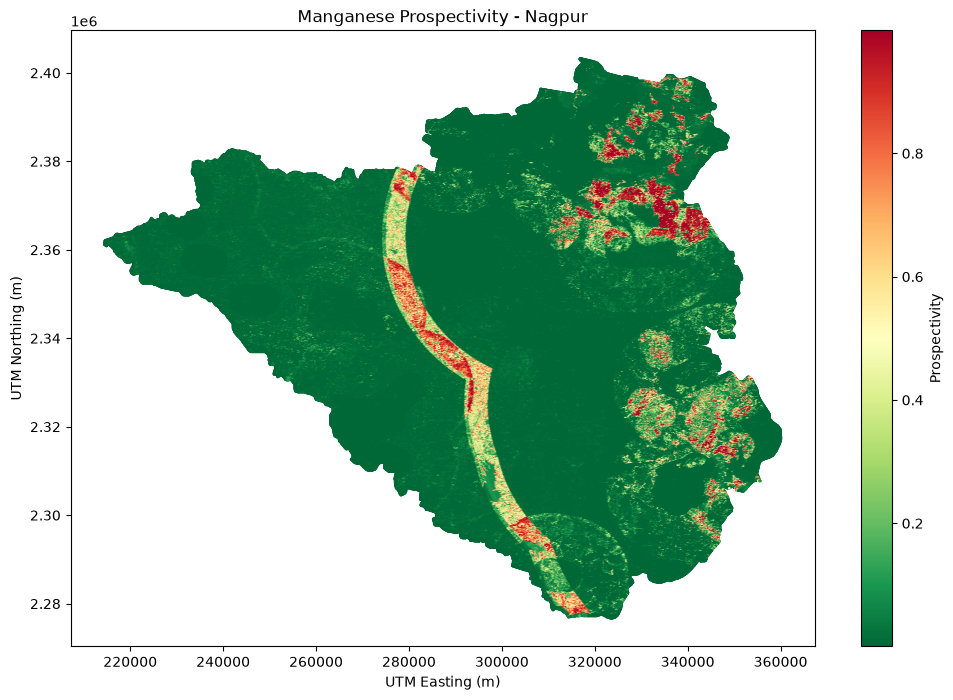

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sc = plt.scatter(
    district_df["x_utm_m"],
    district_df["y_utm_m"],
    c=district_df["prospectivity"],
    s=1,
    cmap="RdYlGn_r"   
)

plt.colorbar(sc, label="Prospectivity")

plt.title("Manganese Prospectivity - Nagpur")
plt.xlabel("UTM Easting (m)")
plt.ylabel("UTM Northing (m)")

plt.show()

In [29]:
district_df = df[df["district"] == "Chhindwara"].copy()
print(district_df.shape)

(1180942, 31)


In [30]:
print(district_df[["x_utm_m","y_utm_m"]].head())

         x_utm_m    y_utm_m
924269  317550.0  2524350.0
924270  317650.0  2524350.0
924271  317250.0  2524250.0
924272  317350.0  2524250.0
924273  317450.0  2524250.0


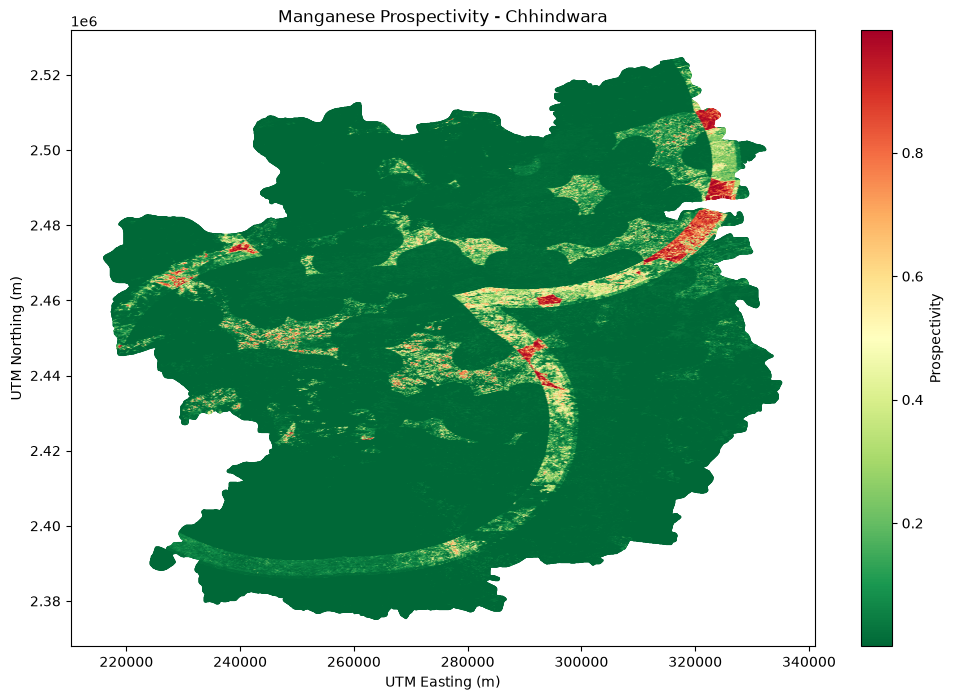

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sc = plt.scatter(
    district_df["x_utm_m"],
    district_df["y_utm_m"],
    c=district_df["prospectivity"],
    s=1,
    cmap="RdYlGn_r"   
)

plt.colorbar(sc, label="Prospectivity")

plt.title("Manganese Prospectivity - Chhindwara")
plt.xlabel("UTM Easting (m)")
plt.ylabel("UTM Northing (m)")

plt.show()

In [32]:
district_df = df[df["district"] == "Balaghat"].copy()
print(district_df.shape)

(924269, 31)


In [33]:
print(district_df[["x_utm_m","y_utm_m"]].head())

    x_utm_m    y_utm_m
0  479750.0  2476950.0
1  479850.0  2476950.0
2  478650.0  2476850.0
3  478750.0  2476850.0
4  478850.0  2476850.0


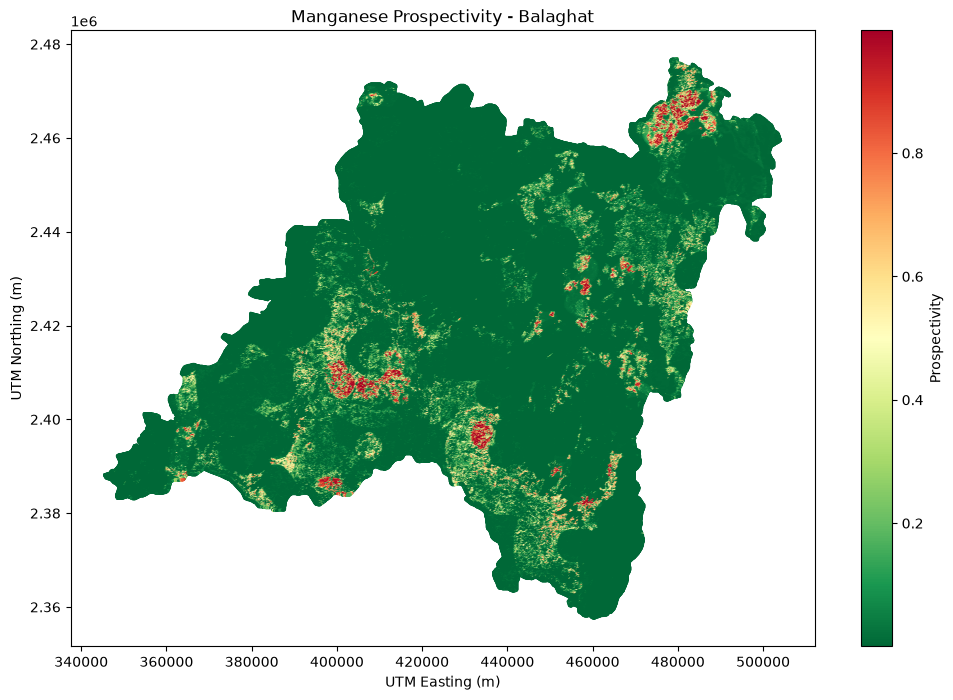

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sc = plt.scatter(
    district_df["x_utm_m"],
    district_df["y_utm_m"],
    c=district_df["prospectivity"],
    s=1,
    cmap="RdYlGn_r"   
)

plt.colorbar(sc, label="Prospectivity")

plt.title("Manganese Prospectivity - Balaghat")
plt.xlabel("UTM Easting (m)")
plt.ylabel("UTM Northing (m)")

plt.show()

In [35]:
district_df = df[df["district"] == "Bhandara"].copy()
print(district_df.shape)

(469880, 31)


In [36]:
print(district_df[["x_utm_m","y_utm_m"]].head())

          x_utm_m    y_utm_m
3098035  368850.0  2389350.0
3098036  368650.0  2389250.0
3098037  368750.0  2389250.0
3098038  368850.0  2389250.0
3098039  368950.0  2389250.0


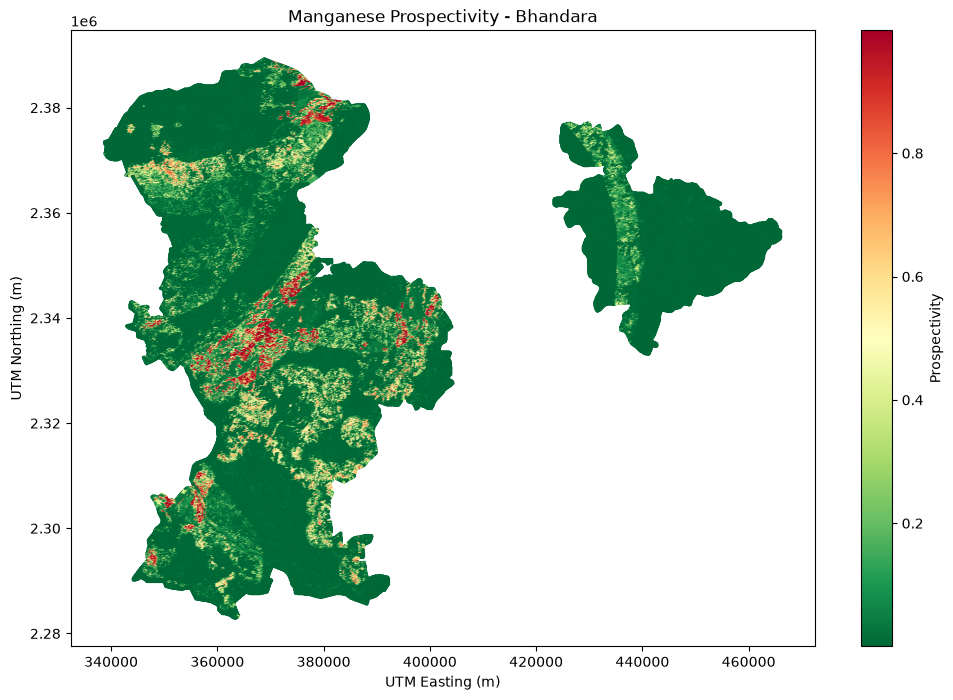

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sc = plt.scatter(
    district_df["x_utm_m"],
    district_df["y_utm_m"],
    c=district_df["prospectivity"],
    s=1,
    cmap="RdYlGn_r"   
)

plt.colorbar(sc, label="Prospectivity")

plt.title("Manganese Prospectivity - Bhandara")
plt.xlabel("UTM Easting (m)")
plt.ylabel("UTM Northing (m)")

plt.show()

In [38]:
df["district"]

0          Balaghat
1          Balaghat
2          Balaghat
3          Balaghat
4          Balaghat
             ...   
3567910    Bhandara
3567911    Bhandara
3567912    Bhandara
3567913    Bhandara
3567914    Bhandara
Name: district, Length: 3567915, dtype: object

In [39]:
district_summary = (
    df.groupby("district")["prospectivity"]
      .agg(["count", "mean", "max"])
      .sort_values("mean", ascending=False)
)

print(district_summary)

              count      mean       max
district                               
Bhandara     469880  0.090663  0.998986
Nagpur       992824  0.081592  0.999269
Balaghat     924269  0.056205  0.998695
Chhindwara  1180942  0.047816  0.998102


In [40]:
high_zone = df[df["prospectivity"] > 0.75]

print(
    high_zone.groupby("district")
             .size()
             .sort_values(ascending=False)
)

district
Nagpur        36653
Balaghat      15578
Chhindwara    14172
Bhandara      12861
dtype: int64


In [43]:
high_targets = df[df["prospectivity"] > 0.75].copy()

high_targets["longitude"], high_targets["latitude"] = transformer.transform(
    high_targets["x_utm_m"].values,
    high_targets["y_utm_m"].values
)

high_targets[
    [
        "district",
        "latitude",
        "longitude",
        "prospectivity"
    ]
].to_csv(
    "high_prospectivity_targets.csv",
    index=False
)

print("Number of high-potential targets:", len(high_targets))

Number of high-potential targets: 79264
